<a href="https://colab.research.google.com/github/Deekshith0625/Machine_Learning/blob/main/PsyStyle_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "vishalbsadanand/deepfashion-1"
)

print("Dataset location:", dataset_path)

100%|██████████| 5.70G/5.70G [01:04<00:00, 94.9MB/s]

Extracting files...


Dataset location: /root/.cache/kagglehub/datasets/vishalbsadanand/deepfashion-1/versions/1


In [ ]:
import os

train_dir = os.path.join(
    dataset_path,
    "datasets",
    "train_images"
)

test_dir = os.path.join(
    dataset_path,
    "datasets",
    "test_images"
)

print("Training folder:", train_dir)
print("Testing folder:", test_dir)

Training folder: /root/.cache/kagglehub/datasets/vishalbsadanand/deepfashion-1/versions/1/datasets/train_images
Testing folder: /root/.cache/kagglehub/datasets/vishalbsadanand/deepfashion-1/versions/1/datasets/test_images


In [ ]:
train_images = [
    f for f in os.listdir(train_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

test_images = [
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of training images:", len(train_images))
print("Number of testing images:", len(test_images))

print("\nSample training filenames:")
for filename in train_images[:5]:
    print(filename)

Number of training images: 10335
Number of testing images: 1149

Sample training filenames:
WOMEN-Tees_Tanks-id_00005702-14_4_full.png
WOMEN-Pants-id_00007657-04_1_front.png
MEN-Sweaters-id_00005878-04_4_full.png
WOMEN-Pants-id_00000052-03_4_full.png
WOMEN-Rompers_Jumpsuits-id_00001849-02_7_additional.png


In [ ]:
def extract_category(filename):
    return filename.split("-id_")[0].split("-", 1)[1]


# Test the function on a few images
for filename in train_images[:5]:
    print(filename)
    print("Category:", extract_category(filename))
    print()

WOMEN-Tees_Tanks-id_00005702-14_4_full.png
Category: Tees_Tanks

WOMEN-Pants-id_00007657-04_1_front.png
Category: Pants

MEN-Sweaters-id_00005878-04_4_full.png
Category: Sweaters

WOMEN-Pants-id_00000052-03_4_full.png
Category: Pants

WOMEN-Rompers_Jumpsuits-id_00001849-02_7_additional.png
Category: Rompers_Jumpsuits



In [ ]:
category_mapping = {
    "Sweaters": "Sweater",
    "Blouses_Shirts": "Shirt",
    "Tees_Tanks": "T-Shirt",
    "Jackets_Vests": "Jacket",
    "Dresses": "Dress",
    "Shorts": "Shorts",
    "Denim": "Jeans",
    "Graphic_Tees": "T-Shirt",
    "Shirts_Polos": "Shirt",
    "Sweatshirts_Hoodies": "Hoodie",
    "Pants": "Trousers",
    "Cardigans": "Cardigan",
    "Skirts": "Skirt",
    "Rompers_Jumpsuits": "Romper",
    "Jackets_Coats": "Jacket",
    "Leggings": "Leggings",
    "Suiting": "Suit"
}

print("Category mapping created.")

Category mapping created.


In [ ]:
import pandas as pd

data = []

for filename in train_images:
    original_category = extract_category(filename)
    category = category_mapping[original_category]
    image_path = os.path.join(train_dir, filename)

    data.append({
        "image_path": image_path,
        "original_category": original_category,
        "category": category
    })

df = pd.DataFrame(data)

print("Number of images:", len(df))
print("Number of columns:", len(df.columns))

df.head()

Number of images: 10335
Number of columns: 3


,image_path,original_category,category
0,/root/.cache/kagglehub/datasets/vishalbsadanan...,Tees_Tanks,T-Shirt
1,/root/.cache/kagglehub/datasets/vishalbsadanan...,Pants,Trousers
2,/root/.cache/kagglehub/datasets/vishalbsadanan...,Sweaters,Sweater
3,/root/.cache/kagglehub/datasets/vishalbsadanan...,Pants,Trousers
4,/root/.cache/kagglehub/datasets/vishalbsadanan...,Rompers_Jumpsuits,Romper


In [ ]:
class_names = sorted(df["category"].unique())

class_to_index = {
    name: index
    for index, name in enumerate(class_names)
}

index_to_class = {
    index: name
    for name, index in class_to_index.items()
}

df["label"] = df["category"].map(class_to_index)

print("Number of classes:", len(class_names))
print("\nClass mapping:")

for index, name in index_to_class.items():
    print(index, "→", name)

Number of classes: 14

Class mapping:
0 → Cardigan
1 → Dress
2 → Hoodie
3 → Jacket
4 → Jeans
5 → Leggings
6 → Romper
7 → Shirt
8 → Shorts
9 → Skirt
10 → Suit
11 → Sweater
12 → T-Shirt
13 → Trousers


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training images: 8268
Validation images: 2067


In [ ]:
test_data = []

for filename in test_images:
    original_category = extract_category(filename)
    category = category_mapping[original_category]
    image_path = os.path.join(test_dir, filename)

    test_data.append({
        "image_path": image_path,
        "original_category": original_category,
        "category": category
    })

test_df = pd.DataFrame(test_data)

# Convert categories to the same numerical labels
test_df["label"] = test_df["category"].map(class_to_index)

print("Test images:", len(test_df))
print("\nTest DataFrame:")
print(test_df.head())

Test images: 1149

Test DataFrame:
                                          image_path original_category  \
0  /root/.cache/kagglehub/datasets/vishalbsadanan...           Dresses   
1  /root/.cache/kagglehub/datasets/vishalbsadanan...      Shirts_Polos   
2  /root/.cache/kagglehub/datasets/vishalbsadanan...             Denim   
3  /root/.cache/kagglehub/datasets/vishalbsadanan...        Tees_Tanks   
4  /root/.cache/kagglehub/datasets/vishalbsadanan...        Tees_Tanks   

  category  label  
0    Dress      1  
1    Shirt      7  
2    Jeans      4  
3  T-Shirt     12  
4  T-Shirt     12  


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(image_path, label):
    # Read image file
    image = tf.io.read_file(image_path)

    # Decode PNG image
    image = tf.image.decode_png(image, channels=3)

    # Resize to ResNet50 input size
    image = tf.image.resize(image, IMG_SIZE)

    # Convert to float32
    image = tf.cast(image, tf.float32)

    # ResNet50-specific preprocessing
    image = preprocess_input(image)

    return image, label

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(1000)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [ ]:

images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First image shape:", images[0].shape)
print("First label:", labels[0].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
First image shape: (224, 224, 3)
First label: 7


In [ ]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("ResNet50 base model created.")
print("Trainable:", base_model.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base model created.
Trainable: False


In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,854 (91.99 MB)

 Trainable params: 528,142 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
base_model.trainable = True

# Keep earlier layers frozen
for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Total ResNet50 layers:", len(base_model.layers))
print("Trainable ResNet50 layers:", sum(
    layer.trainable for layer in base_model.layers
))

Total ResNet50 layers: 175
Trainable ResNet50 layers: 20


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
for class_index, weight in class_weights.items():
    print(f"{index_to_class[class_index]}: {weight:.2f}")

Class weights:
Cardigan: 2.12
Dress: 0.38
Hoodie: 2.79
Jacket: 1.47
Jeans: 5.05
Leggings: 10.94
Romper: 1.35
Shirt: 0.50
Shorts: 1.21
Skirt: 2.17
Suit: 98.43
Sweater: 1.10
T-Shirt: 0.27
Trousers: 1.23


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 140s 430ms/step - accuracy: 0.1091 - loss: 2.6276 - val_accuracy: 0.2075 - val_loss: 2.3577
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 106s 374ms/step - accuracy: 0.2136 - loss: 2.0631 - val_accuracy: 0.2830 - val_loss: 2.1033
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 103s 360ms/step - accuracy: 0.3070 - loss: 1.7362 - val_accuracy: 0.3493 - val_loss: 1.9237
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 104s 367ms/step - accuracy: 0.3719 - loss: 1.4461 - val_accuracy: 0.4059 - val_loss: 1.7545
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 104s 365ms/step - accuracy: 0.4311 - loss: 1.2741 - val_accuracy: 0.4306 - val_loss: 1.6642
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 105s 370ms/step - accuracy: 0.4809 - loss: 1.1111 - val_accuracy: 0.4785 - val_loss: 1.5559
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 104s 364ms/step - accuracy: 0.5357 - loss: 0.9792 - val_accuracy: 0.5060 - val_loss: 1.4752
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 106s 374ms/step - accuracy: 0.5785 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 539ms/step - accuracy: 0.5474 - loss: 1.3565
Test Loss: 1.3565384149551392
Test Accuracy: 0.547432541847229


In [ ]:
y_true = test_df["label"].values

y_prob = model.predict(test_dataset)

y_pred = np.argmax(y_prob, axis=1)

print("Number of actual labels:", len(y_true))
print("Number of predictions:", len(y_pred))

36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 374ms/step
Number of actual labels: 1149
Number of predictions: 1149


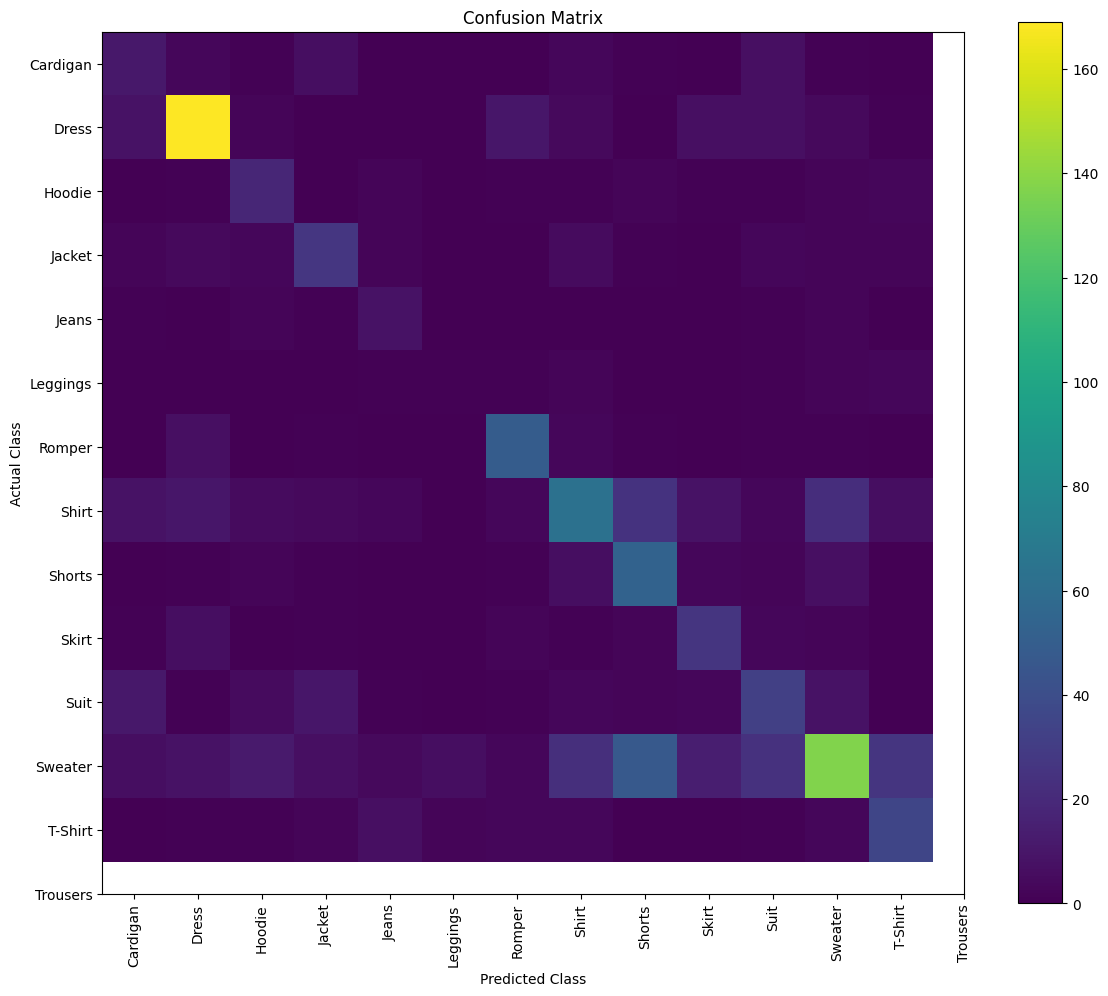

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

    Cardigan       0.23      0.33      0.27        33
       Dress       0.80      0.80      0.80       212
      Hoodie       0.35      0.56      0.43        32
      Jacket       0.45      0.53      0.49        51
       Jeans       0.29      0.53      0.37        15
    Leggings       0.11      0.09      0.10        11
      Romper       0.66      0.78      0.72        63
       Shirt       0.54      0.39      0.45       160
      Shorts       0.40      0.70      0.50        76
       Skirt       0.42      0.59      0.49        44
        Suit       0.00      0.00      0.00         0
     Sweater       0.37      0.42      0.39        77
     T-Shirt       0.71      0.43      0.54       317
    Trousers       0.46      0.60      0.52        58

    accuracy                           0.55      1149
   macro avg       0.41      0.48      0.43      1149
weighted avg       0.59      0.55      0.55      1149



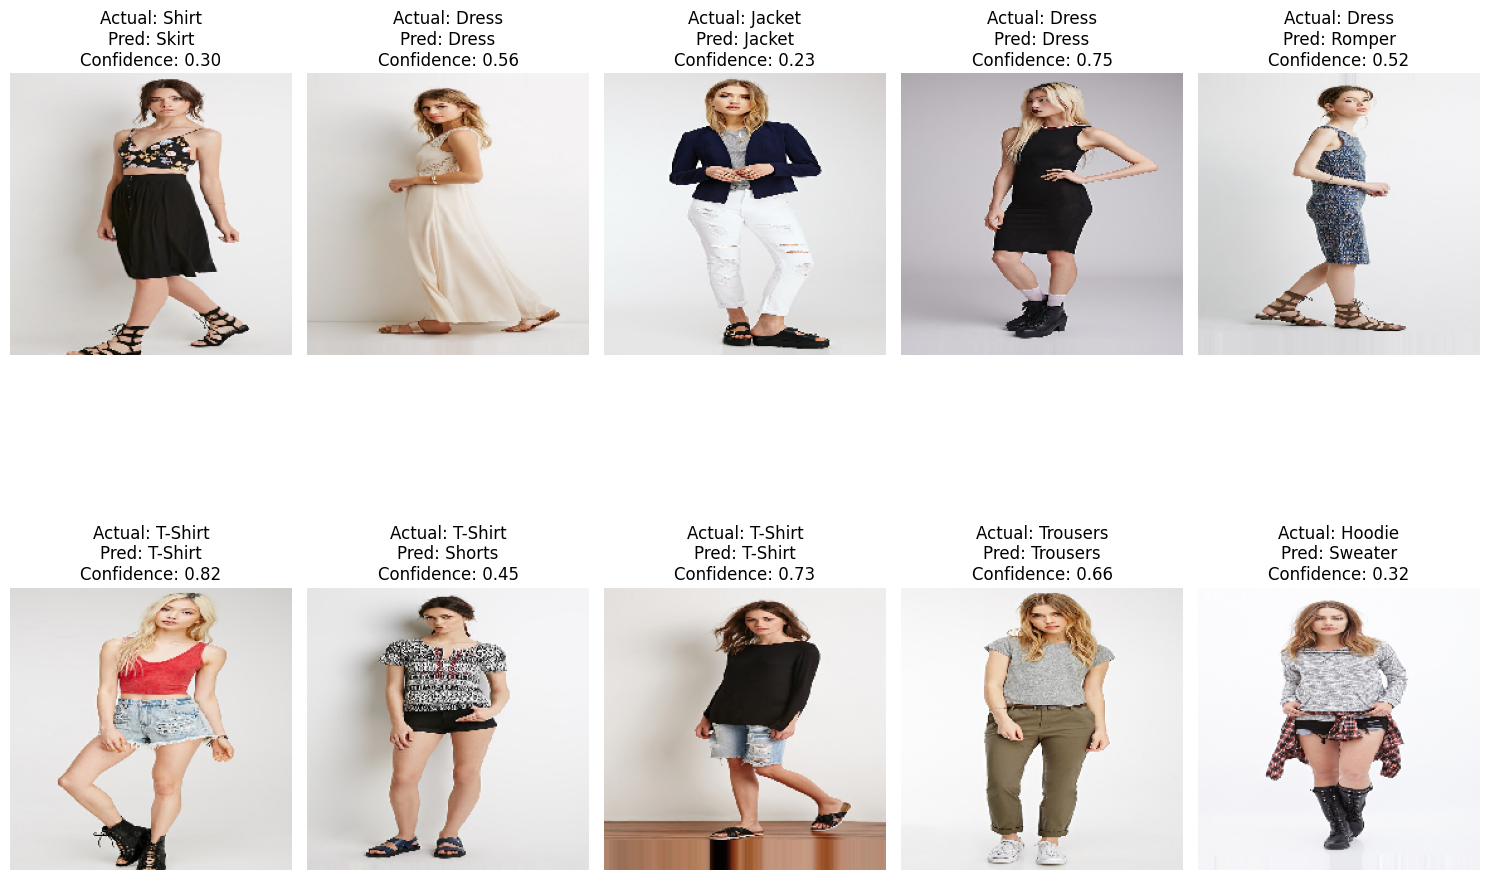

In [ ]:
import random
import matplotlib.pyplot as plt

sample_indices = random.sample(range(len(test_df)), 10)

plt.figure(figsize=(15, 12))

for i, index in enumerate(sample_indices):
    image_path = test_df.iloc[index]["image_path"]

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    actual = index_to_class[y_true[index]]
    predicted = index_to_class[y_pred[index]]
    confidence = y_prob[index][y_pred[index]]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {predicted}\n"
        f"Confidence: {confidence:.2f}"
    )

plt.tight_layout()
plt.show()

In [ ]:
model.save("psystyle_resnet50_clothing.keras")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation created.")

Data augmentation created.


In [ ]:
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

print("Data augmentation added to the model.")

Data augmentation added to the model.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Augmented model compiled successfully.")

Augmented model compiled successfully.


In [ ]:
aug_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 126s 378ms/step - accuracy: 0.2008 - loss: 2.4311 - val_accuracy: 0.3212 - val_loss: 2.0313
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 135s 379ms/step - accuracy: 0.3337 - loss: 1.7347 - val_accuracy: 0.3962 - val_loss: 1.8340
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 110s 388ms/step - accuracy: 0.4022 - loss: 1.5204 - val_accuracy: 0.4427 - val_loss: 1.6628
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 140s 385ms/step - accuracy: 0.4480 - loss: 1.3128 - val_accuracy: 0.4659 - val_loss: 1.6192
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 108s 382ms/step - accuracy: 0.4817 - loss: 1.2040 - val_accuracy: 0.4978 - val_loss: 1.5509
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 107s 380ms/step - accuracy: 0.5075 - loss: 1.0930 - val_accuracy: 0.5162 - val_loss: 1.4852
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 108s 384ms/step - accuracy: 0.5434 - loss: 1.0204 - val_accuracy: 0.5230 - val_loss: 1.4922
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 141s 387ms/step - accuracy: 0.5577 -

In [ ]:
aug_test_loss, aug_test_accuracy = model.evaluate(test_dataset)

print("Augmented Model Test Loss:", aug_test_loss)
print("Augmented Model Test Accuracy:", aug_test_accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 475ms/step - accuracy: 0.5396 - loss: 1.4794
Augmented Model Test Loss: 1.4794350862503052
Augmented Model Test Accuracy: 0.5395996570587158


In [ ]:
model = tf.keras.models.load_model(
    "psystyle_resnet50_clothing.keras"
)

print("Best saved model loaded successfully.")

Best saved model loaded successfully.


In [ ]:
class_counts = train_df["category"].value_counts().sort_index()

print("Training images per class:\n")
print(class_counts)

Training images per class:

category
Cardigan     278
Dress       1567
Hoodie       212
Jacket       403
Jeans        117
Leggings      54
Romper       439
Shirt       1184
Shorts       490
Skirt        272
Suit           6
Sweater      539
T-Shirt     2227
Trousers     480
Name: count, dtype: int64


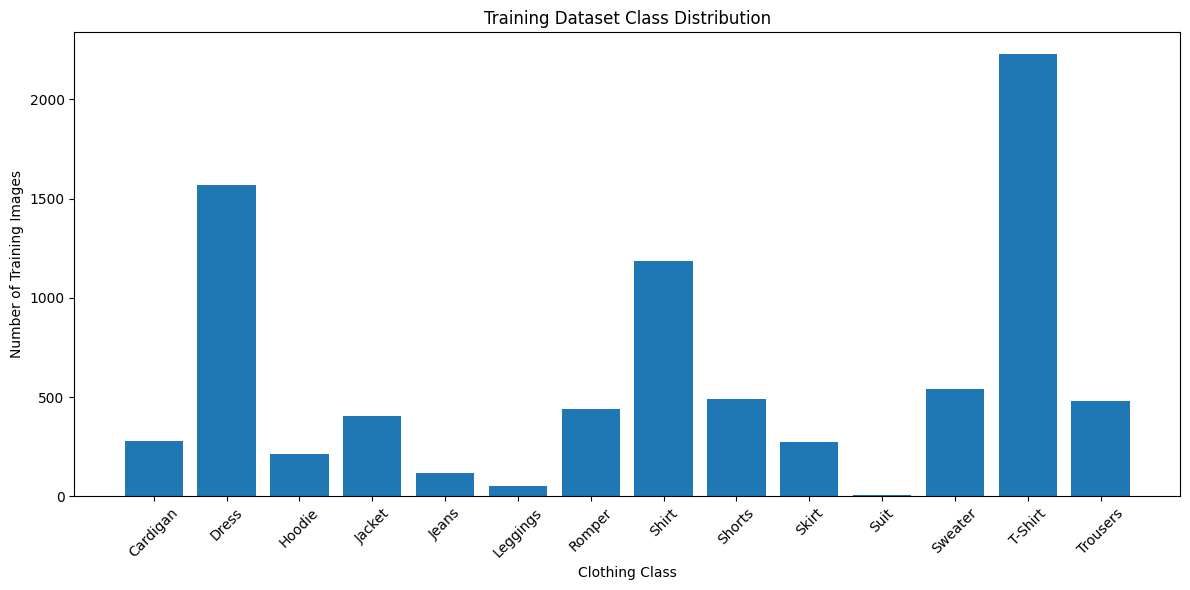

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Clothing Class")
plt.ylabel("Number of Training Images")
plt.title("Training Dataset Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest class:", largest_class)
print("Smallest class:", smallest_class)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Largest class: 2227
Smallest class: 6
Imbalance ratio: 371.17


In [ ]:
rare_classes = class_counts[class_counts < 100]

print("Rare classes (< 100 training images):\n")
print(rare_classes)

Rare classes (< 100 training images):

category
Leggings    54
Suit         6
Name: count, dtype: int64


In [ ]:
print("Rare classes and their image counts:\n")

for class_name, count in rare_classes.items():
    print(f"{class_name}: {count}")

Rare classes and their image counts:

Leggings: 54
Suit: 6


In [ ]:
val_class_counts = val_df["category"].value_counts().sort_index()

print("Rare classes in validation set:\n")

for class_name in rare_classes.index:
    print(
        f"{class_name}: "
        f"{val_class_counts.get(class_name, 0)} images"
    )

Rare classes in validation set:

Leggings: 13 images
Suit: 2 images


In [ ]:
print("Current class weights:\n")

for class_index, weight in class_weights.items():
    print(f"{index_to_class[class_index]}: {weight:.2f}")

Current class weights:

Cardigan: 2.12
Dress: 0.38
Hoodie: 2.79
Jacket: 1.47
Jeans: 5.05
Leggings: 10.94
Romper: 1.35
Shirt: 0.50
Shorts: 1.21
Skirt: 2.17
Suit: 98.43
Sweater: 1.10
T-Shirt: 0.27
Trousers: 1.23


In [ ]:
print("Current class weights:\n")

for class_index, weight in class_weights.items():
    print(f"{index_to_class[class_index]}: {weight:.2f}")

Current class weights:

Cardigan: 2.12
Dress: 0.38
Hoodie: 2.79
Jacket: 1.47
Jeans: 5.05
Leggings: 10.94
Romper: 1.35
Shirt: 0.50
Shorts: 1.21
Skirt: 2.17
Suit: 98.43
Sweater: 1.10
T-Shirt: 0.27
Trousers: 1.23


In [ ]:
adjusted_class_weights = class_weights.copy()

suit_index = class_to_index["Suit"]

adjusted_class_weights[suit_index] = 1.0

print("Adjusted class weights:\n")

for class_index, weight in adjusted_class_weights.items():
    print(f"{index_to_class[class_index]}: {weight:.2f}")

Adjusted class weights:

Cardigan: 2.12
Dress: 0.38
Hoodie: 2.79
Jacket: 1.47
Jeans: 5.05
Leggings: 10.94
Romper: 1.35
Shirt: 0.50
Shorts: 1.21
Skirt: 2.17
Suit: 1.00
Sweater: 1.10
T-Shirt: 0.27
Trousers: 1.23


In [ ]:
adjusted_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    class_weight=adjusted_class_weights
)

Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 132s 400ms/step - accuracy: 0.7021 - loss: 0.5433 - val_accuracy: 0.5801 - val_loss: 1.2746
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 101s 356ms/step - accuracy: 0.7398 - loss: 0.4654 - val_accuracy: 0.5931 - val_loss: 1.2390
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 143s 358ms/step - accuracy: 0.7773 - loss: 0.3862 - val_accuracy: 0.5859 - val_loss: 1.2374
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 101s 354ms/step - accuracy: 0.8061 - loss: 0.3284 - val_accuracy: 0.6023 - val_loss: 1.2395
Epoch 5/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 103s 361ms/step - accuracy: 0.8394 - loss: 0.2702 - val_accuracy: 0.6091 - val_loss: 1.2186


In [ ]:
adjusted_test_loss, adjusted_test_accuracy = model.evaluate(test_dataset)

print("Adjusted Model Test Loss:", adjusted_test_loss)
print("Adjusted Model Test Accuracy:", adjusted_test_accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 566ms/step - accuracy: 0.5970 - loss: 1.2943
Adjusted Model Test Loss: 1.294304609298706
Adjusted Model Test Accuracy: 0.5970408916473389


In [ ]:
model.save("psystyle_resnet50_best.keras")

print("Best PsyStyle model saved successfully.")

Best PsyStyle model saved successfully.


In [ ]:
moods = [
    "Happy",
    "Calm",
    "Nervous",
    "Sad",
    "Energetic",
    "Confident"
]

personalities = [
    "Introvert",
    "Extrovert",
    "Balanced"
]

occasions = [
    "College",
    "Interview",
    "Party",
    "Wedding",
    "Casual"
]

confidence_levels = list(range(1, 11))

print("Moods:", moods)
print("Personalities:", personalities)
print("Occasions:", occasions)
print("Confidence levels:", confidence_levels)

Moods: ['Happy', 'Calm', 'Nervous', 'Sad', 'Energetic', 'Confident']
Personalities: ['Introvert', 'Extrovert', 'Balanced']
Occasions: ['College', 'Interview', 'Party', 'Wedding', 'Casual']
Confidence levels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
occasion_preferences = {
    "College": ["T-Shirt", "Jeans", "Shirt", "Trousers", "Hoodie"],
    "Interview": ["Shirt", "Trousers", "Suit", "Jacket"],
    "Party": ["Dress", "Shirt", "T-Shirt", "Skirt", "Jacket"],
    "Wedding": ["Dress", "Suit", "Shirt", "Jacket", "Skirt"],
    "Casual": ["T-Shirt", "Jeans", "Shorts", "Hoodie", "Sweater"]
}

print("Occasion preferences created.")

Occasion preferences created.


In [ ]:
mood_preferences = {
    "Happy": ["T-Shirt", "Dress", "Skirt", "Shorts"],
    "Calm": ["Sweater", "Cardigan", "Trousers", "Shirt"],
    "Nervous": ["Hoodie", "Sweater", "Cardigan", "Trousers"],
    "Sad": ["Hoodie", "Sweater", "Cardigan", "Jeans"],
    "Energetic": ["T-Shirt", "Shorts", "Jeans", "Jacket"],
    "Confident": ["Jacket", "Suit", "Dress", "Shirt"]
}

print("Mood preferences created.")

Mood preferences created.


In [ ]:
personality_preferences = {
    "Introvert": ["Cardigan", "Sweater", "Shirt", "Trousers", "Hoodie"],
    "Extrovert": ["T-Shirt", "Jacket", "Dress", "Shorts", "Skirt"],
    "Balanced": ["Shirt", "T-Shirt", "Jeans", "Trousers", "Jacket"]
}

print("Personality preferences created.")

Personality preferences created.


In [ ]:
confidence_preferences = {
    "Low": ["Hoodie", "Sweater", "Cardigan", "T-Shirt"],
    "Moderate": ["T-Shirt", "Shirt", "Jeans", "Trousers", "Dress"],
    "High": ["Jacket", "Suit", "Dress", "Shirt", "Skirt"]
}

def get_confidence_level(confidence):
    if confidence <= 3:
        return "Low"
    elif confidence <= 7:
        return "Moderate"
    else:
        return "High"

print("Confidence preference system created.")

Confidence preference system created.


In [ ]:
def calculate_score(category, mood, personality, occasion, confidence):
    score = 0

    if category in occasion_preferences[occasion]:
        score += 1

    if category in mood_preferences[mood]:
        score += 1

    if category in personality_preferences[personality]:
        score += 1

    confidence_level = get_confidence_level(confidence)

    if category in confidence_preferences[confidence_level]:
        score += 1

    return score


print("Recommendation scoring function created.")

Recommendation scoring function created.


In [ ]:
test_mood = "Confident"
test_personality = "Extrovert"
test_occasion = "Party"
test_confidence = 9

test_categories = class_names

test_scores = {}

for category in test_categories:
    test_scores[category] = calculate_score(
        category,
        test_mood,
        test_personality,
        test_occasion,
        test_confidence
    )

print("Scores for the test user:\n")

for category, score in sorted(
    test_scores.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{category}: {score}")

Scores for the test user:

Dress: 4
Jacket: 4
Shirt: 3
Skirt: 3
Suit: 2
T-Shirt: 2
Shorts: 1
Cardigan: 0
Hoodie: 0
Jeans: 0
Leggings: 0
Romper: 0
Sweater: 0
Trousers: 0


In [ ]:
def rank_categories(mood, personality, occasion, confidence):
    scores = {}

    for category in class_names:
        scores[category] = calculate_score(
            category,
            mood,
            personality,
            occasion,
            confidence
        )

    ranked_categories = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked_categories


print("Category ranking function created.")

Category ranking function created.


In [ ]:
def get_context_score(
    predicted_category,
    mood,
    personality,
    occasion,
    confidence
):
    return calculate_score(
        predicted_category,
        mood,
        personality,
        occasion,
        confidence
    )


print("ResNet50-to-context scoring function created.")

ResNet50-to-context scoring function created.


In [ ]:
def recommend_categories(mood, personality, occasion, confidence):
    ranked_categories = rank_categories(
        mood,
        personality,
        occasion,
        confidence
    )

    return ranked_categories


print("Final category recommendation function created.")

Final category recommendation function created.


In [ ]:
mood = "Confident"
personality = "Extrovert"
occasion = "Party"
confidence = 9

recommendations = recommend_categories(
    mood,
    personality,
    occasion,
    confidence
)

print("Recommended clothing categories:\n")

for category, score in recommendations:
    print(f"{category}: {score}/4")

Recommended clothing categories:

Dress: 4/4
Jacket: 4/4
Shirt: 3/4
Skirt: 3/4
Suit: 2/4
T-Shirt: 2/4
Shorts: 1/4
Cardigan: 0/4
Hoodie: 0/4
Jeans: 0/4
Leggings: 0/4
Romper: 0/4
Sweater: 0/4
Trousers: 0/4


In [ ]:
def predict_clothing(image_path):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    image_array = preprocess_input(image_array)

    predictions = model.predict(image_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    predicted_category = index_to_class[predicted_index]
    confidence = predictions[0][predicted_index]

    return predicted_category, confidence


print("Clothing prediction function created.")

Clothing prediction function created.


In [ ]:
sample_image_path = test_df.iloc[0]["image_path"]

predicted_category, confidence = predict_clothing(
    sample_image_path
)

print("Image:", os.path.basename(sample_image_path))
print("Predicted category:", predicted_category)
print("Confidence:", round(confidence * 100, 2), "%")

Image: WOMEN-Dresses-id_00001714-01_4_full.png
Predicted category: T-Shirt
Confidence: 71.1 %


In [ ]:
mood = "Confident"
personality = "Extrovert"
occasion = "Party"
confidence = 9

context_score = get_context_score(
    predicted_category,
    mood,
    personality,
    occasion,
    confidence
)

print("Predicted clothing:", predicted_category)
print("Model confidence:", round(confidence * 100, 2), "%")
print("Context score:", context_score, "/ 4")

Predicted clothing: T-Shirt
Model confidence: 900 %
Context score: 2 / 4


In [ ]:
def score_wardrobe_item(
    image_path,
    mood,
    personality,
    occasion,
    confidence
):
    predicted_category, model_confidence = predict_clothing(
        image_path
    )

    context_score = get_context_score(
        predicted_category,
        mood,
        personality,
        occasion,
        confidence
    )

    return {
        "image_path": image_path,
        "category": predicted_category,
        "model_confidence": model_confidence,
        "context_score": context_score
    }


print("Wardrobe item scoring function created.")

Wardrobe item scoring function created.


In [ ]:
item_result = score_wardrobe_item(
    sample_image_path,
    "Confident",
    "Extrovert",
    "Party",
    9
)

print("Clothing category:", item_result["category"])
print(
    "Model confidence:",
    round(item_result["model_confidence"] * 100, 2),
    "%"
)
print("Context score:", item_result["context_score"], "/ 4")

Clothing category: T-Shirt
Model confidence: 71.1 %
Context score: 2 / 4


In [ ]:
wardrobe_results = []

print("Wardrobe results list created.")

Wardrobe results list created.


In [ ]:
for image_path in test_df["image_path"].head(10):
    result = score_wardrobe_item(
        image_path,
        "Confident",
        "Extrovert",
        "Party",
        9
    )

    wardrobe_results.append(result)

print("Number of wardrobe items processed:", len(wardrobe_results))

Number of wardrobe items processed: 10


In [ ]:
ranked_wardrobe = sorted(
    wardrobe_results,
    key=lambda x: x["context_score"],
    reverse=True
)

print("Wardrobe recommendations:\n")

for i, item in enumerate(ranked_wardrobe, start=1):
    print(
        f"{i}. {item['category']} | "
        f"Context score: {item['context_score']}/4 | "
        f"Model confidence: "
        f"{item['model_confidence'] * 100:.2f}%"
    )

Wardrobe recommendations:

1. Dress | Context score: 4/4 | Model confidence: 47.69%
2. T-Shirt | Context score: 2/4 | Model confidence: 71.10%
3. T-Shirt | Context score: 2/4 | Model confidence: 75.88%
4. T-Shirt | Context score: 2/4 | Model confidence: 51.14%
5. T-Shirt | Context score: 2/4 | Model confidence: 49.41%
6. Shorts | Context score: 1/4 | Model confidence: 66.41%
7. Sweater | Context score: 0/4 | Model confidence: 81.33%
8. Cardigan | Context score: 0/4 | Model confidence: 28.03%
9. Sweater | Context score: 0/4 | Model confidence: 53.79%
10. Romper | Context score: 0/4 | Model confidence: 92.42%


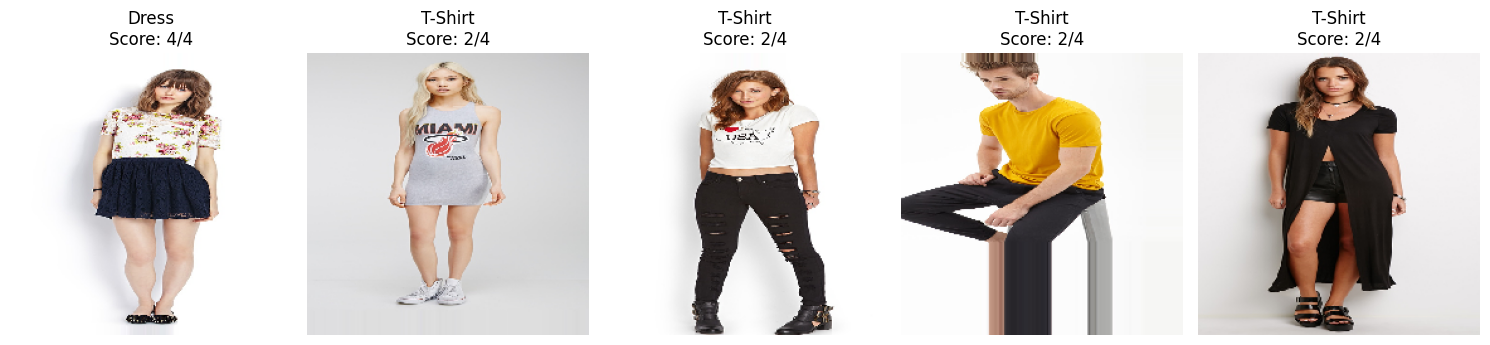

In [ ]:
import matplotlib.pyplot as plt

top_items = ranked_wardrobe[:5]

plt.figure(figsize=(15, 8))

for i, item in enumerate(top_items):
    image = tf.keras.utils.load_img(
        item["image_path"],
        target_size=IMG_SIZE
    )

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"{item['category']}\n"
        f"Score: {item['context_score']}/4"
    )

plt.tight_layout()
plt.show()

In [ ]:
def recommend_wardrobe(
    image_paths,
    mood,
    personality,
    occasion,
    confidence
):
    results = []

    for image_path in image_paths:
        result = score_wardrobe_item(
            image_path,
            mood,
            personality,
            occasion,
            confidence
        )

        results.append(result)

    results = sorted(
        results,
        key=lambda x: x["context_score"],
        reverse=True
    )

    return results


print("Dynamic wardrobe recommendation function created.")

Dynamic wardrobe recommendation function created.


In [ ]:
dynamic_recommendations = recommend_wardrobe(
    test_df["image_path"].head(10),
    mood="Nervous",
    personality="Introvert",
    occasion="Interview",
    confidence=4
)

print("Top wardrobe recommendations:\n")

for i, item in enumerate(dynamic_recommendations, start=1):
    print(
        f"{i}. {item['category']} | "
        f"Context score: {item['context_score']}/4 | "
        f"Model confidence: "
        f"{item['model_confidence'] * 100:.2f}%"
    )

Top wardrobe recommendations:

1. Sweater | Context score: 2/4 | Model confidence: 81.33%
2. Cardigan | Context score: 2/4 | Model confidence: 28.03%
3. Sweater | Context score: 2/4 | Model confidence: 53.79%
4. T-Shirt | Context score: 1/4 | Model confidence: 71.10%
5. T-Shirt | Context score: 1/4 | Model confidence: 75.88%
6. T-Shirt | Context score: 1/4 | Model confidence: 51.14%
7. Dress | Context score: 1/4 | Model confidence: 47.69%
8. T-Shirt | Context score: 1/4 | Model confidence: 49.41%
9. Romper | Context score: 0/4 | Model confidence: 92.42%
10. Shorts | Context score: 0/4 | Model confidence: 66.41%


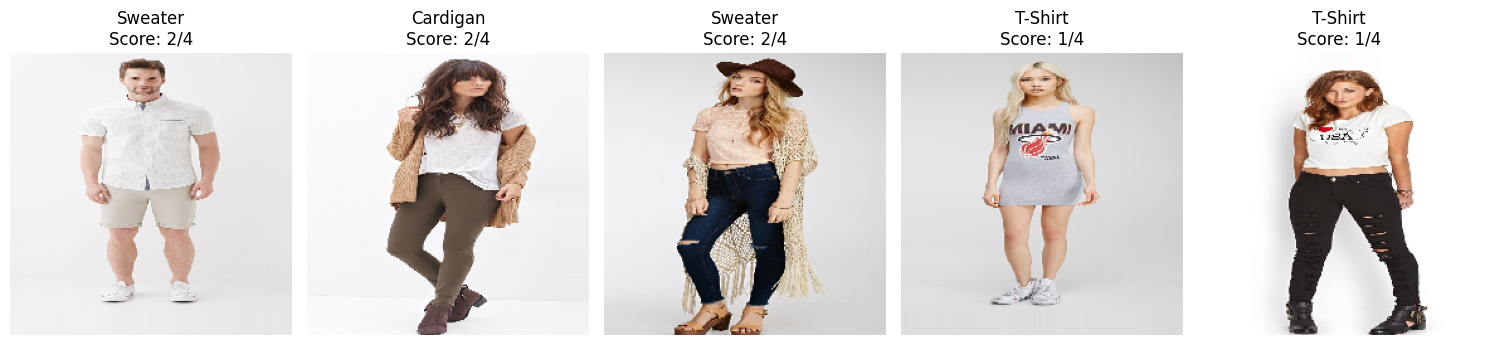

In [ ]:
top_dynamic = dynamic_recommendations[:5]

plt.figure(figsize=(15, 8))

for i, item in enumerate(top_dynamic):
    image = tf.keras.utils.load_img(
        item["image_path"],
        target_size=IMG_SIZE
    )

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"{item['category']}\n"
        f"Score: {item['context_score']}/4"
    )

plt.tight_layout()
plt.show()

In [ ]:
def calculate_final_score(context_score, model_confidence):
    context_score_normalized = context_score / 4

    final_score = (
        0.70 * context_score_normalized
        + 0.30 * model_confidence
    )

    return final_score


print("Final recommendation scoring function created.")

Final recommendation scoring function created.


In [ ]:
for item in dynamic_recommendations:
    item["final_score"] = calculate_final_score(
        item["context_score"],
        item["model_confidence"]
    )

print("Final scores added to all wardrobe items.")

Final scores added to all wardrobe items.


In [ ]:
final_recommendations = sorted(
    dynamic_recommendations,
    key=lambda x: x["final_score"],
    reverse=True
)

print("Final wardrobe recommendations:\n")

for i, item in enumerate(final_recommendations, start=1):
    print(
        f"{i}. {item['category']} | "
        f"Final Score: {item['final_score']:.3f} | "
        f"Context: {item['context_score']}/4 | "
        f"Model Confidence: "
        f"{item['model_confidence'] * 100:.2f}%"
    )

Final wardrobe recommendations:

1. Sweater | Final Score: 0.594 | Context: 2/4 | Model Confidence: 81.33%
2. Sweater | Final Score: 0.511 | Context: 2/4 | Model Confidence: 53.79%
3. Cardigan | Final Score: 0.434 | Context: 2/4 | Model Confidence: 28.03%
4. T-Shirt | Final Score: 0.403 | Context: 1/4 | Model Confidence: 75.88%
5. T-Shirt | Final Score: 0.388 | Context: 1/4 | Model Confidence: 71.10%
6. T-Shirt | Final Score: 0.328 | Context: 1/4 | Model Confidence: 51.14%
7. T-Shirt | Final Score: 0.323 | Context: 1/4 | Model Confidence: 49.41%
8. Dress | Final Score: 0.318 | Context: 1/4 | Model Confidence: 47.69%
9. Romper | Final Score: 0.277 | Context: 0/4 | Model Confidence: 92.42%
10. Shorts | Final Score: 0.199 | Context: 0/4 | Model Confidence: 66.41%


In [ ]:
def get_recommendations(
    image_paths,
    mood,
    personality,
    occasion,
    confidence
):
    recommendations = recommend_wardrobe(
        image_paths,
        mood,
        personality,
        occasion,
        confidence
    )

    for item in recommendations:
        item["final_score"] = calculate_final_score(
            item["context_score"],
            item["model_confidence"]
        )

    recommendations = sorted(
        recommendations,
        key=lambda x: x["final_score"],
        reverse=True
    )

    return recommendations


print("Final recommendation function created.")

Final recommendation function created.


In [ ]:
final_result = get_recommendations(
    test_df["image_path"].head(10),
    mood="Happy",
    personality="Balanced",
    occasion="College",
    confidence=7
)

print("PsyStyle Recommendations:\n")

for i, item in enumerate(final_result, start=1):
    print(
        f"{i}. {item['category']} | "
        f"Final Score: {item['final_score']:.3f}"
    )


PsyStyle Recommendations:

1. T-Shirt | Final Score: 0.928
2. T-Shirt | Final Score: 0.913
3. T-Shirt | Final Score: 0.853
4. T-Shirt | Final Score: 0.848
5. Dress | Final Score: 0.493
6. Shorts | Final Score: 0.374
7. Romper | Final Score: 0.277
8. Sweater | Final Score: 0.244
9. Sweater | Final Score: 0.161
10. Cardigan | Final Score: 0.084


In [ ]:
outfit_groups = {
    "Tops": [
        "T-Shirt",
        "Shirt",
        "Sweater",
        "Hoodie",
        "Cardigan",
        "Jacket"
    ],
    "Bottoms": [
        "Jeans",
        "Trousers",
        "Shorts",
        "Skirt",
        "Leggings"
    ],
    "One-Piece": [
        "Dress",
        "Romper",
        "Suit"
    ]
}

print("Outfit groups created.")

for group, categories in outfit_groups.items():
    print(f"{group}: {categories}")

Outfit groups created.
Tops: ['T-Shirt', 'Shirt', 'Sweater', 'Hoodie', 'Cardigan', 'Jacket']
Bottoms: ['Jeans', 'Trousers', 'Shorts', 'Skirt', 'Leggings']
One-Piece: ['Dress', 'Romper', 'Suit']


In [ ]:
def get_outfit_group(category):
    for group, categories in outfit_groups.items():
        if category in categories:
            return group

    return "Other"


print("Outfit group function created.")

Outfit group function created.


In [ ]:
tops = []
bottoms = []
one_piece = []

for item in final_result:
    group = get_outfit_group(item["category"])

    if group == "Tops":
        tops.append(item)
    elif group == "Bottoms":
        bottoms.append(item)
    elif group == "One-Piece":
        one_piece.append(item)

print("Tops:", len(tops))
print("Bottoms:", len(bottoms))
print("One-Piece:", len(one_piece))

Tops: 7
Bottoms: 1
One-Piece: 2


In [ ]:
if tops and bottoms:
    best_top = tops[0]
    best_bottom = bottoms[0]

    outfit_score = (
        best_top["final_score"] +
        best_bottom["final_score"]
    ) / 2

    print("Recommended Outfit:")
    print(f"Top: {best_top['category']}")
    print(f"Bottom: {best_bottom['category']}")
    print(f"Outfit Score: {outfit_score:.3f}")

else:
    print("Not enough top and bottom items to create an outfit.")

Recommended Outfit:
Top: T-Shirt
Bottom: Shorts
Outfit Score: 0.651


In [ ]:
outfit_combinations = []

for top in tops:
    for bottom in bottoms:
        outfit_score = (
            top["final_score"] +
            bottom["final_score"]
        ) / 2

        outfit_combinations.append({
            "top": top,
            "bottom": bottom,
            "outfit_score": outfit_score
        })

outfit_combinations = sorted(
    outfit_combinations,
    key=lambda x: x["outfit_score"],
    reverse=True
)

print("Number of outfit combinations:", len(outfit_combinations))

Number of outfit combinations: 7


In [ ]:
print("Top outfit combinations:\n")

for i, outfit in enumerate(outfit_combinations[:5], start=1):
    print(
        f"{i}. "
        f"{outfit['top']['category']} + "
        f"{outfit['bottom']['category']} | "
        f"Score: {outfit['outfit_score']:.3f}"
    )

Top outfit combinations:

1. T-Shirt + Shorts | Score: 0.651
2. T-Shirt + Shorts | Score: 0.644
3. T-Shirt + Shorts | Score: 0.614
4. T-Shirt + Shorts | Score: 0.611
5. Sweater + Shorts | Score: 0.309


In [ ]:
one_piece_outfits = []

for item in one_piece:
    one_piece_outfits.append({
        "item": item,
        "outfit_score": item["final_score"]
    })

one_piece_outfits = sorted(
    one_piece_outfits,
    key=lambda x: x["outfit_score"],
    reverse=True
)

print("One-piece outfit recommendations:\n")

for i, outfit in enumerate(one_piece_outfits, start=1):
    print(
        f"{i}. {outfit['item']['category']} | "
        f"Score: {outfit['outfit_score']:.3f}"
    )

One-piece outfit recommendations:

1. Dress | Score: 0.493
2. Romper | Score: 0.277


In [ ]:
all_outfits = []

# Add top + bottom combinations
for outfit in outfit_combinations:
    all_outfits.append({
        "type": "Top + Bottom",
        "top": outfit["top"],
        "bottom": outfit["bottom"],
        "score": outfit["outfit_score"]
    })

# Add one-piece outfits
for outfit in one_piece_outfits:
    all_outfits.append({
        "type": "One-Piece",
        "item": outfit["item"],
        "score": outfit["outfit_score"]
    })

# Sort everything by score
all_outfits = sorted(
    all_outfits,
    key=lambda x: x["score"],
    reverse=True
)

print("Total outfit recommendations:", len(all_outfits))

Total outfit recommendations: 9


In [ ]:
print("Top 5 PsyStyle Outfits:\n")

for i, outfit in enumerate(all_outfits[:5], start=1):
    print(f"{i}. {outfit['type']} | Score: {outfit['score']:.3f}")

    if outfit["type"] == "Top + Bottom":
        print(f"   Top: {outfit['top']['category']}")
        print(f"   Bottom: {outfit['bottom']['category']}")
    else:
        print(f"   Item: {outfit['item']['category']}")

    print()

Top 5 PsyStyle Outfits:

1. Top + Bottom | Score: 0.651
   Top: T-Shirt
   Bottom: Shorts

2. Top + Bottom | Score: 0.644
   Top: T-Shirt
   Bottom: Shorts

3. Top + Bottom | Score: 0.614
   Top: T-Shirt
   Bottom: Shorts

4. Top + Bottom | Score: 0.611
   Top: T-Shirt
   Bottom: Shorts

5. One-Piece | Score: 0.493
   Item: Dress



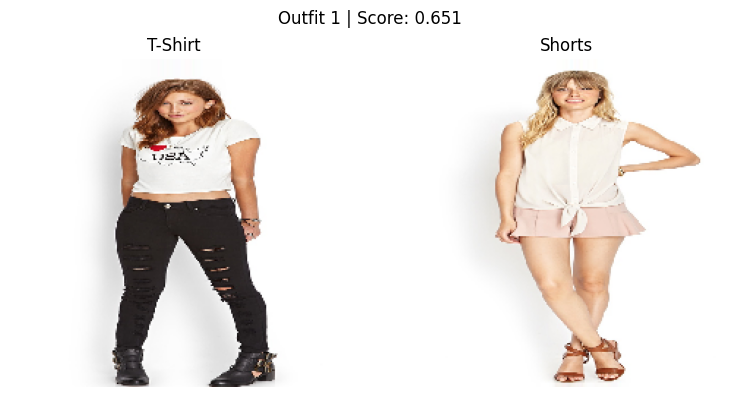

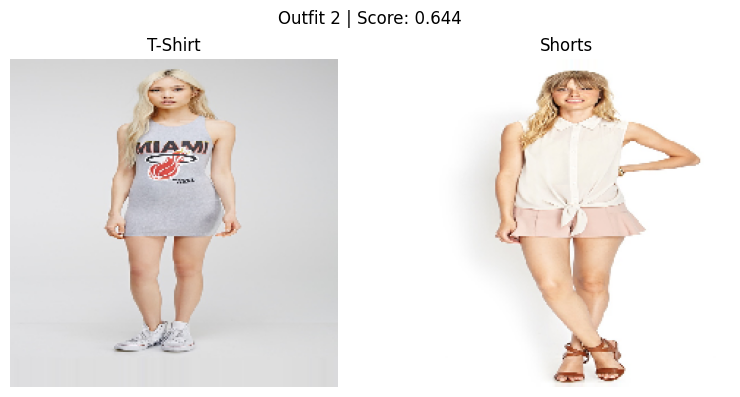

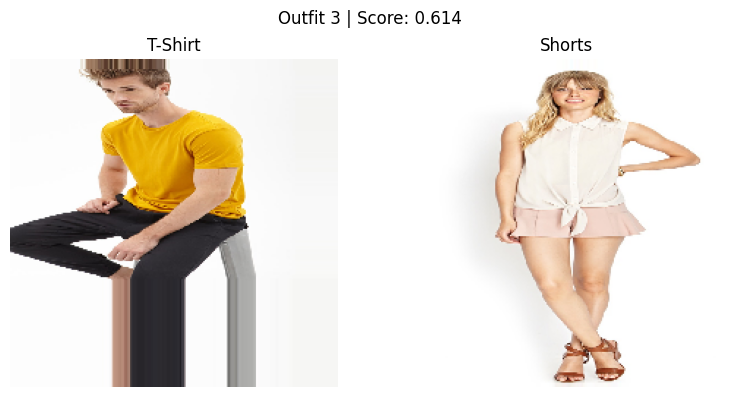

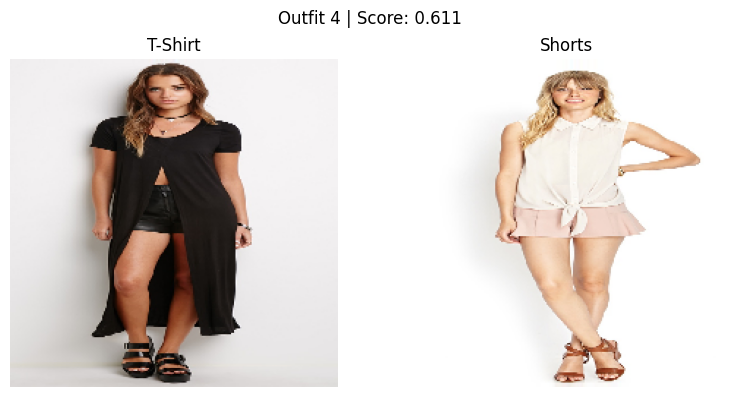

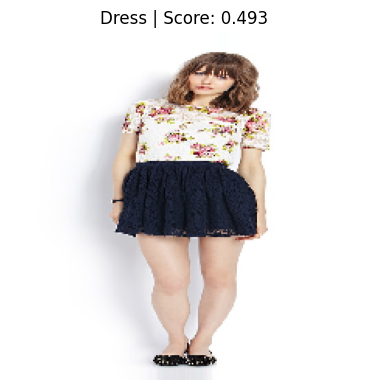

In [ ]:
for i, outfit in enumerate(all_outfits[:5], start=1):

    plt.figure(figsize=(8, 4))

    if outfit["type"] == "Top + Bottom":

        top_image = tf.keras.utils.load_img(
            outfit["top"]["image_path"],
            target_size=IMG_SIZE
        )

        bottom_image = tf.keras.utils.load_img(
            outfit["bottom"]["image_path"],
            target_size=IMG_SIZE
        )

        plt.subplot(1, 2, 1)
        plt.imshow(top_image)
        plt.axis("off")
        plt.title(outfit["top"]["category"])

        plt.subplot(1, 2, 2)
        plt.imshow(bottom_image)
        plt.axis("off")
        plt.title(outfit["bottom"]["category"])

        plt.suptitle(
            f"Outfit {i} | Score: {outfit['score']:.3f}"
        )

    else:

        item_image = tf.keras.utils.load_img(
            outfit["item"]["image_path"],
            target_size=IMG_SIZE
        )

        plt.imshow(item_image)
        plt.axis("off")
        plt.title(
            f"{outfit['item']['category']} | "
            f"Score: {outfit['score']:.3f}"
        )

    plt.tight_layout()
    plt.show()

In [ ]:
compatible_bottoms = {
    "T-Shirt": ["Jeans", "Trousers", "Shorts", "Skirt"],
    "Shirt": ["Jeans", "Trousers", "Shorts", "Skirt"],
    "Sweater": ["Jeans", "Trousers", "Skirt"],
    "Hoodie": ["Jeans", "Trousers", "Shorts"],
    "Cardigan": ["Jeans", "Trousers", "Skirt"],
    "Jacket": ["Jeans", "Trousers", "Shorts", "Skirt"]
}

print("Outfit compatibility rules created.")

Outfit compatibility rules created.


In [ ]:
compatible_outfit_combinations = []

for outfit in outfit_combinations:
    top_category = outfit["top"]["category"]
    bottom_category = outfit["bottom"]["category"]

    if bottom_category in compatible_bottoms.get(top_category, []):
        compatible_outfit_combinations.append(outfit)

print(
    "Compatible outfit combinations:",
    len(compatible_outfit_combinations)
)

Compatible outfit combinations: 4


In [ ]:
compatible_outfit_combinations = sorted(
    compatible_outfit_combinations,
    key=lambda x: x["outfit_score"],
    reverse=True
)

print("Top compatible outfits:\n")

for i, outfit in enumerate(
    compatible_outfit_combinations[:5],
    start=1
):
    print(
        f"{i}. "
        f"{outfit['top']['category']} + "
        f"{outfit['bottom']['category']} | "
        f"Score: {outfit['outfit_score']:.3f}"
    )

Top compatible outfits:

1. T-Shirt + Shorts | Score: 0.651
2. T-Shirt + Shorts | Score: 0.644
3. T-Shirt + Shorts | Score: 0.614
4. T-Shirt + Shorts | Score: 0.611


In [ ]:
final_outfits = []

# Add compatible Top + Bottom outfits
for outfit in compatible_outfit_combinations:
    final_outfits.append({
        "type": "Top + Bottom",
        "top": outfit["top"],
        "bottom": outfit["bottom"],
        "score": outfit["outfit_score"]
    })

# Add One-Piece outfits
for outfit in one_piece_outfits:
    final_outfits.append({
        "type": "One-Piece",
        "item": outfit["item"],
        "score": outfit["outfit_score"]
    })

# Rank all final outfits
final_outfits = sorted(
    final_outfits,
    key=lambda x: x["score"],
    reverse=True
)

print("Final number of outfits:", len(final_outfits))

Final number of outfits: 6


In [ ]:
print("Final PsyStyle Outfit Recommendations:\n")

for i, outfit in enumerate(final_outfits[:5], start=1):
    print(f"Recommendation {i}")
    print(f"Type: {outfit['type']}")
    print(f"Score: {outfit['score']:.3f}")

    if outfit["type"] == "Top + Bottom":
        print(f"Top: {outfit['top']['category']}")
        print(f"Bottom: {outfit['bottom']['category']}")
    else:
        print(f"Outfit: {outfit['item']['category']}")

    print("-" * 40)

Final PsyStyle Outfit Recommendations:

Recommendation 1
Type: Top + Bottom
Score: 0.651
Top: T-Shirt
Bottom: Shorts
----------------------------------------
Recommendation 2
Type: Top + Bottom
Score: 0.644
Top: T-Shirt
Bottom: Shorts
----------------------------------------
Recommendation 3
Type: Top + Bottom
Score: 0.614
Top: T-Shirt
Bottom: Shorts
----------------------------------------
Recommendation 4
Type: Top + Bottom
Score: 0.611
Top: T-Shirt
Bottom: Shorts
----------------------------------------
Recommendation 5
Type: One-Piece
Score: 0.493
Outfit: Dress
----------------------------------------


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        print("\nFolder:", root)
        for f in image_files[:10]:
            print(" ", f)


Folder: /content/wardrobe
  jeans.jpg
  hoodie.jpg
  jacket.jpg
  trouser.jpg
  shirt.jpg


In [ ]:
wardrobe_dir = "/content/wardrobe"

wardrobe_images = [
    os.path.join(wardrobe_dir, filename)
    for filename in os.listdir(wardrobe_dir)
    if filename.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Wardrobe images:", len(wardrobe_images))

for image_path in wardrobe_images:
    print(os.path.basename(image_path))

Wardrobe images: 5
jeans.jpg
hoodie.jpg
jacket.jpg
trouser.jpg
shirt.jpg


In [ ]:
wardrobe_predictions = []

for image_path in wardrobe_images:
    category, confidence = predict_clothing(image_path)

    wardrobe_predictions.append({
        "image_path": image_path,
        "category": category,
        "confidence": confidence
    })

for item in wardrobe_predictions:
    print(
        f"{os.path.basename(item['image_path'])} → "
        f"{item['category']} "
        f"({item['confidence'] * 100:.2f}%)"
    )

jeans.jpg → Dress (33.73%)
hoodie.jpg → Trousers (72.68%)
jacket.jpg → Sweater (26.35%)
trouser.jpg → Shirt (27.71%)
shirt.jpg → Sweater (18.77%)


In [ ]:
wardrobe_categories = {
    "jeans.jpg": "Jeans",
    "hoodie.jpg": "Hoodie",
    "jacket.jpg": "Jacket",
    "trouser.jpg": "Trousers",
    "shirt.jpg": "Shirt"
}

wardrobe_df = pd.DataFrame([
    {
        "image_path": os.path.join(wardrobe_dir, filename),
        "category": category,
        "group": get_outfit_group(category)
    }
    for filename, category in wardrobe_categories.items()
])

print("Wardrobe dataset:\n")
print(wardrobe_df)

Wardrobe dataset:

                      image_path  category    group
0    /content/wardrobe/jeans.jpg     Jeans  Bottoms
1   /content/wardrobe/hoodie.jpg    Hoodie     Tops
2   /content/wardrobe/jacket.jpg    Jacket     Tops
3  /content/wardrobe/trouser.jpg  Trousers  Bottoms
4    /content/wardrobe/shirt.jpg     Shirt     Tops


In [ ]:
user_mood = "Confident"
user_personality = "Extrovert"
user_occasion = "Party"
user_confidence = 9

wardrobe_df["context_score"] = wardrobe_df["category"].apply(
    lambda category: calculate_score(
        category,
        user_mood,
        user_personality,
        user_occasion,
        user_confidence
    )
)

wardrobe_df = wardrobe_df.sort_values(
    "context_score",
    ascending=False
)

print("Your wardrobe recommendations:\n")
print(
    wardrobe_df[
        ["category", "group", "context_score"]
    ].to_string(index=False)
)

Your wardrobe recommendations:

category   group  context_score
  Jacket    Tops              4
   Shirt    Tops              3
   Jeans Bottoms              0
  Hoodie    Tops              0
Trousers Bottoms              0


In [ ]:
wardrobe_outfits = []

tops = wardrobe_df[wardrobe_df["group"] == "Tops"].to_dict("records")
bottoms = wardrobe_df[wardrobe_df["group"] == "Bottoms"].to_dict("records")

for top in tops:
    for bottom in bottoms:

        if bottom["category"] in compatible_bottoms.get(
            top["category"], []
        ):
            outfit_score = (
                top["context_score"] +
                bottom["context_score"]
            ) / 2

            wardrobe_outfits.append({
                "top": top,
                "bottom": bottom,
                "score": outfit_score
            })

wardrobe_outfits = sorted(
    wardrobe_outfits,
    key=lambda x: x["score"],
    reverse=True
)

print("Recommended outfits from your wardrobe:\n")

for i, outfit in enumerate(wardrobe_outfits, 1):
    print(
        f"{i}. {outfit['top']['category']} + "
        f"{outfit['bottom']['category']} "
        f"| Score: {outfit['score']:.2f}"
    )

Recommended outfits from your wardrobe:

1. Jacket + Jeans | Score: 2.00
2. Jacket + Trousers | Score: 2.00
3. Shirt + Jeans | Score: 1.50
4. Shirt + Trousers | Score: 1.50
5. Hoodie + Jeans | Score: 0.00
6. Hoodie + Trousers | Score: 0.00


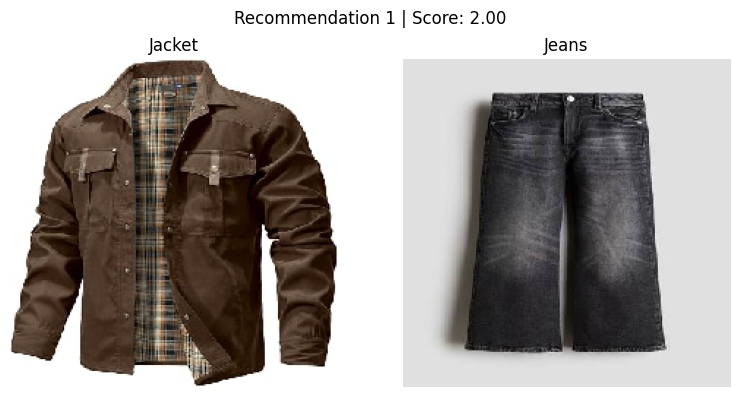

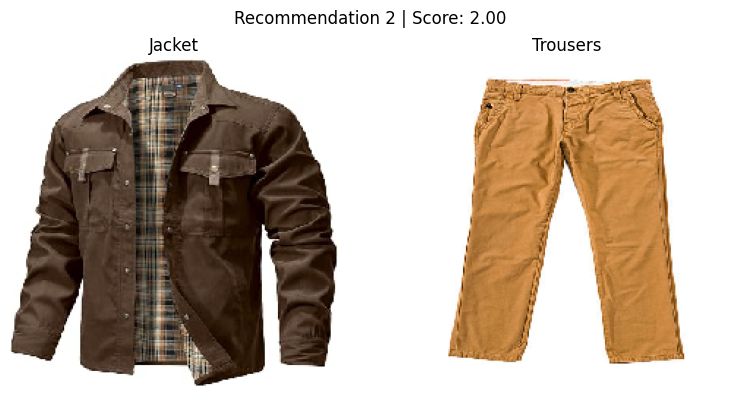

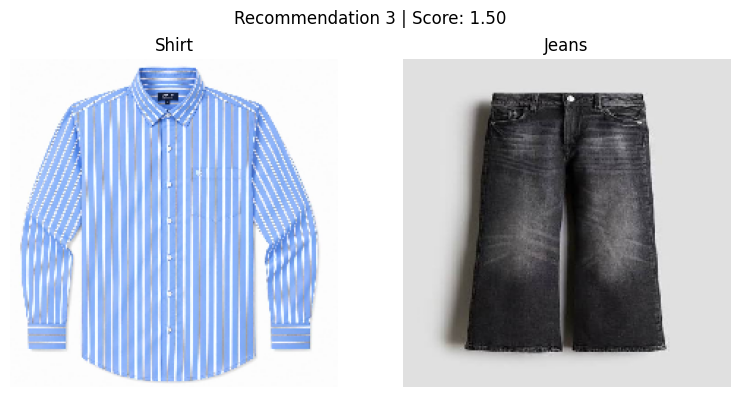

In [ ]:
for i, outfit in enumerate(wardrobe_outfits[:3], start=1):

    top_image = tf.keras.utils.load_img(
        outfit["top"]["image_path"],
        target_size=IMG_SIZE
    )

    bottom_image = tf.keras.utils.load_img(
        outfit["bottom"]["image_path"],
        target_size=IMG_SIZE
    )

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(top_image)
    plt.axis("off")
    plt.title(outfit["top"]["category"])

    plt.subplot(1, 2, 2)
    plt.imshow(bottom_image)
    plt.axis("off")
    plt.title(outfit["bottom"]["category"])

    plt.suptitle(
        f"Recommendation {i} | "
        f"Score: {outfit['score']:.2f}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def psystyle_recommend(
    mood,
    personality,
    occasion,
    confidence
):
    wardrobe_scored = wardrobe_df.copy()

    wardrobe_scored["context_score"] = wardrobe_scored[
        "category"
    ].apply(
        lambda category: calculate_score(
            category,
            mood,
            personality,
            occasion,
            confidence
        )
    )

    tops = wardrobe_scored[
        wardrobe_scored["group"] == "Tops"
    ].to_dict("records")

    bottoms = wardrobe_scored[
        wardrobe_scored["group"] == "Bottoms"
    ].to_dict("records")

    outfits = []

    for top in tops:
        for bottom in bottoms:

            if bottom["category"] in compatible_bottoms.get(
                top["category"], []
            ):
                score = (
                    top["context_score"] +
                    bottom["context_score"]
                ) / 2

                outfits.append({
                    "top": top,
                    "bottom": bottom,
                    "score": score
                })

    return sorted(
        outfits,
        key=lambda x: x["score"],
        reverse=True
    )


print("PsyStyle recommendation engine is ready.")

PsyStyle recommendation engine is ready.


In [ ]:
%%writefile app.py

import streamlit as st
import os
import tempfile
from PIL import Image


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="PsyStyle",
    page_icon="👗",
    layout="wide"
)


# ============================================================
# PSYSTYLE RULES
# ============================================================

occasion_preferences = {
    "College": [
        "T-Shirt", "Jeans", "Shirt",
        "Trousers", "Hoodie"
    ],

    "Interview": [
        "Shirt", "Trousers",
        "Suit", "Jacket"
    ],

    "Party": [
        "Dress", "Shirt", "T-Shirt",
        "Skirt", "Jacket"
    ],

    "Wedding": [
        "Dress", "Suit", "Shirt",
        "Jacket", "Skirt"
    ],

    "Casual": [
        "T-Shirt", "Jeans",
        "Shorts", "Hoodie",
        "Sweater"
    ]
}


mood_preferences = {
    "Happy": [
        "T-Shirt", "Dress",
        "Skirt", "Shorts"
    ],

    "Calm": [
        "Sweater", "Cardigan",
        "Trousers", "Shirt"
    ],

    "Nervous": [
        "Hoodie", "Sweater",
        "Cardigan", "Trousers"
    ],

    "Sad": [
        "Hoodie", "Sweater",
        "Cardigan", "Jeans"
    ],

    "Energetic": [
        "T-Shirt", "Shorts",
        "Jeans", "Jacket"
    ],

    "Confident": [
        "Jacket", "Suit",
        "Dress", "Shirt"
    ]
}


personality_preferences = {
    "Introvert": [
        "Cardigan", "Sweater",
        "Shirt", "Trousers",
        "Hoodie"
    ],

    "Extrovert": [
        "T-Shirt", "Jacket",
        "Dress", "Shorts",
        "Skirt"
    ],

    "Balanced": [
        "Shirt", "T-Shirt",
        "Jeans", "Trousers",
        "Jacket"
    ]
}


confidence_preferences = {
    "Low": [
        "Hoodie", "Sweater",
        "Cardigan", "T-Shirt"
    ],

    "Moderate": [
        "T-Shirt", "Shirt",
        "Jeans", "Trousers",
        "Dress"
    ],

    "High": [
        "Jacket", "Suit",
        "Dress", "Shirt",
        "Skirt"
    ]
}


compatible_bottoms = {

    "T-Shirt": [
        "Jeans", "Trousers",
        "Shorts", "Skirt"
    ],

    "Shirt": [
        "Jeans", "Trousers",
        "Shorts", "Skirt"
    ],

    "Sweater": [
        "Jeans", "Trousers",
        "Skirt"
    ],

    "Hoodie": [
        "Jeans", "Trousers",
        "Shorts"
    ],

    "Cardigan": [
        "Jeans", "Trousers",
        "Skirt"
    ],

    "Jacket": [
        "Jeans", "Trousers",
        "Shorts", "Skirt"
    ]
}


# ============================================================
# SCORING
# ============================================================

def get_confidence_level(confidence):

    if confidence <= 3:
        return "Low"

    elif confidence <= 7:
        return "Moderate"

    return "High"


def calculate_score(
    category,
    mood,
    personality,
    occasion,
    confidence
):

    score = 0

    if category in occasion_preferences[occasion]:
        score += 1

    if category in mood_preferences[mood]:
        score += 1

    if category in personality_preferences[personality]:
        score += 1

    confidence_level = get_confidence_level(confidence)

    if category in confidence_preferences[
        confidence_level
    ]:
        score += 1

    return score


# ============================================================
# CATEGORY SELECTION
# ============================================================

def select_category(filename):

    name = filename.lower()

    if "jeans" in name:
        return "Jeans"

    if "trouser" in name or "pant" in name:
        return "Trousers"

    if "shirt" in name:
        return "Shirt"

    if "hoodie" in name:
        return "Hoodie"

    if "jacket" in name:
        return "Jacket"

    if "sweater" in name:
        return "Sweater"

    if "tshirt" in name or "t-shirt" in name:
        return "T-Shirt"

    if "short" in name:
        return "Shorts"

    if "skirt" in name:
        return "Skirt"

    if "dress" in name:
        return "Dress"

    if "cardigan" in name:
        return "Cardigan"

    return "Unknown"


# ============================================================
# GROUP CLOTHING
# ============================================================

def get_group(category):

    tops = [
        "T-Shirt",
        "Shirt",
        "Sweater",
        "Hoodie",
        "Cardigan",
        "Jacket"
    ]

    bottoms = [
        "Jeans",
        "Trousers",
        "Shorts",
        "Skirt",
        "Leggings"
    ]

    one_piece = [
        "Dress",
        "Romper",
        "Suit"
    ]

    if category in tops:
        return "Top"

    if category in bottoms:
        return "Bottom"

    if category in one_piece:
        return "One-Piece"

    return "Unknown"


# ============================================================
# BUILD RECOMMENDATIONS
# ============================================================

def generate_recommendations(
    uploaded_images,
    mood,
    personality,
    occasion,
    confidence
):

    wardrobe = []

    for uploaded_file in uploaded_images:

        category = select_category(
            uploaded_file.name
        )

        group = get_group(category)

        wardrobe.append({
            "file": uploaded_file,
            "category": category,
            "group": group,
            "score": calculate_score(
                category,
                mood,
                personality,
                occasion,
                confidence
            )
        })


    tops = [
        item for item in wardrobe
        if item["group"] == "Top"
    ]

    bottoms = [
        item for item in wardrobe
        if item["group"] == "Bottom"
    ]

    one_piece = [
        item for item in wardrobe
        if item["group"] == "One-Piece"
    ]


    outfits = []


    # --------------------------------------------------------
    # TOP + BOTTOM
    # --------------------------------------------------------

    for top in tops:

        for bottom in bottoms:

            if bottom["category"] in compatible_bottoms.get(
                top["category"],
                []
            ):

                score = (
                    top["score"]
                    +
                    bottom["score"]
                ) / 2

                outfits.append({
                    "type": "Top + Bottom",
                    "top": top,
                    "bottom": bottom,
                    "score": score
                })


    # --------------------------------------------------------
    # ONE-PIECE
    # --------------------------------------------------------

    for item in one_piece:

        outfits.append({
            "type": "One-Piece",
            "item": item,
            "score": item["score"]
        })


    return sorted(
        outfits,
        key=lambda x: x["score"],
        reverse=True
    )


# ============================================================
# USER INTERFACE
# ============================================================

st.title("🧠 PsyStyle")

st.subheader(
    "Psychological Outfit Recommendation System"
)

st.write(
    "Upload your wardrobe and tell PsyStyle about "
    "your current mood, personality, occasion and "
    "confidence level."
)

st.divider()


# ============================================================
# WARDROBE INPUT
# ============================================================

st.header("👗 1. Upload Your Wardrobe")

uploaded_images = st.file_uploader(
    "Upload clothing images",
    type=["jpg", "jpeg", "png"],
    accept_multiple_files=True
)

if uploaded_images:

    st.write(
        f"**{len(uploaded_images)} clothing item(s) uploaded.**"
    )

    preview_columns = st.columns(
        min(len(uploaded_images), 5)
    )

    for i, uploaded_file in enumerate(
        uploaded_images
    ):

        with preview_columns[
            i % len(preview_columns)
        ]:

            st.image(
                uploaded_file,
                caption=uploaded_file.name,
                use_container_width=True
            )


st.divider()


# ============================================================
# PSYCHOLOGICAL INPUT
# ============================================================

st.header("🧠 2. Tell Us About Yourself")

col1, col2 = st.columns(2)


with col1:

    mood = st.selectbox(
        "😊 Current Mood",
        [
            "Happy",
            "Calm",
            "Nervous",
            "Sad",
            "Energetic",
            "Confident"
        ]
    )

    personality = st.selectbox(
        "🧠 Personality",
        [
            "Introvert",
            "Extrovert",
            "Balanced"
        ]
    )


with col2:

    occasion = st.selectbox(
        "📅 Occasion",
        [
            "College",
            "Interview",
            "Party",
            "Wedding",
            "Casual"
        ]
    )

    confidence = st.slider(
        "💪 Confidence Level",
        min_value=1,
        max_value=10,
        value=5
    )


st.divider()


# ============================================================
# RECOMMEND BUTTON
# ============================================================

st.header("✨ 3. Get Your Recommendation")


if st.button(
    "✨ Generate My Outfit",
    use_container_width=True
):

    if not uploaded_images:

        st.error(
            "Please upload at least one clothing image."
        )

    else:

        recommendations = generate_recommendations(
            uploaded_images,
            mood,
            personality,
            occasion,
            confidence
        )


        # ----------------------------------------------------
        # SHOW USER INPUT
        # ----------------------------------------------------

        st.success(
            "Your personalized recommendations are ready!"
        )

        st.write("### 🎯 Your Preferences")

        c1, c2, c3, c4 = st.columns(4)

        c1.metric("Mood", mood)
        c2.metric("Personality", personality)
        c3.metric("Occasion", occasion)
        c4.metric(
            "Confidence",
            f"{confidence}/10"
        )


        # ----------------------------------------------------
        # SHOW RECOMMENDATIONS
        # ----------------------------------------------------

        st.write("### 🏆 Recommended Outfits")


        if not recommendations:

            st.warning(
                "No compatible outfit could be created "
                "from the uploaded wardrobe."
            )

        else:

            for i, outfit in enumerate(
                recommendations[:5],
                start=1
            ):

                st.write(
                    f"#### 🏆 Recommendation {i}"
                )

                if outfit["type"] == "Top + Bottom":

                    c1, c2 = st.columns(2)

                    with c1:

                        st.image(
                            outfit["top"]["file"],
                            caption=(
                                "Top: "
                                + outfit["top"]["category"]
                            ),
                            use_container_width=True
                        )

                    with c2:

                        st.image(
                            outfit["bottom"]["file"],
                            caption=(
                                "Bottom: "
                                + outfit["bottom"]["category"]
                            ),
                            use_container_width=True
                        )

                    st.write(
                        "**Outfit:** "
                        + outfit["top"]["category"]
                        + " + "
                        + outfit["bottom"]["category"]
                    )

                else:

                    st.image(
                        outfit["item"]["file"],
                        caption=outfit["item"]["category"],
                        width=300
                    )

                    st.write(
                        "**Outfit:** "
                        + outfit["item"]["category"]
                    )


                st.write(
                    f"**PsyStyle Score:** "
                    f"{outfit['score']:.2f}/4"
                )

                st.divider()

Overwriting app.py


In [ ]:
!ngrok config add-authtoken 3J5u3K8PShadnUo8wLjFb3kKzas_7h1MWNX5B9MbW4XCPiv8f

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:


from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("🚀 PsyStyle is running!")
print("Open this URL:")
print(public_url)

🚀 PsyStyle is running!
Open this URL:
NgrokTunnel: "https://vertebrae-defiant-squishier.ngrok-free.dev" -> "http://localhost:8501"
